# Harsh Cleaning

Let's start off with our base cleaned dataset, but this time do a much harsher cleaning on all fronts.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

In [11]:
df = pd.read_parquet("../all_car_details_cleaned.parquet")

Let's see some base statistics.

In [12]:
initial_size = df.shape[0]
print(f"Initial size of dataset: {initial_size}")

Initial size of dataset: 468148


In [56]:
def plot_numeric_columns(df):
    # These are the numeric columns:
    numeric_cols = ['price', 'mileage', 'power',
                    'age_months', 'fuel_consumption', 'co2_emissions']

    # Define the number of rows and columns for your subplot grid.
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()  # Flatten to simplify iterating

    for i, col in enumerate(numeric_cols):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f'Boxplot of {col}')

    # Remove any unused axes if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

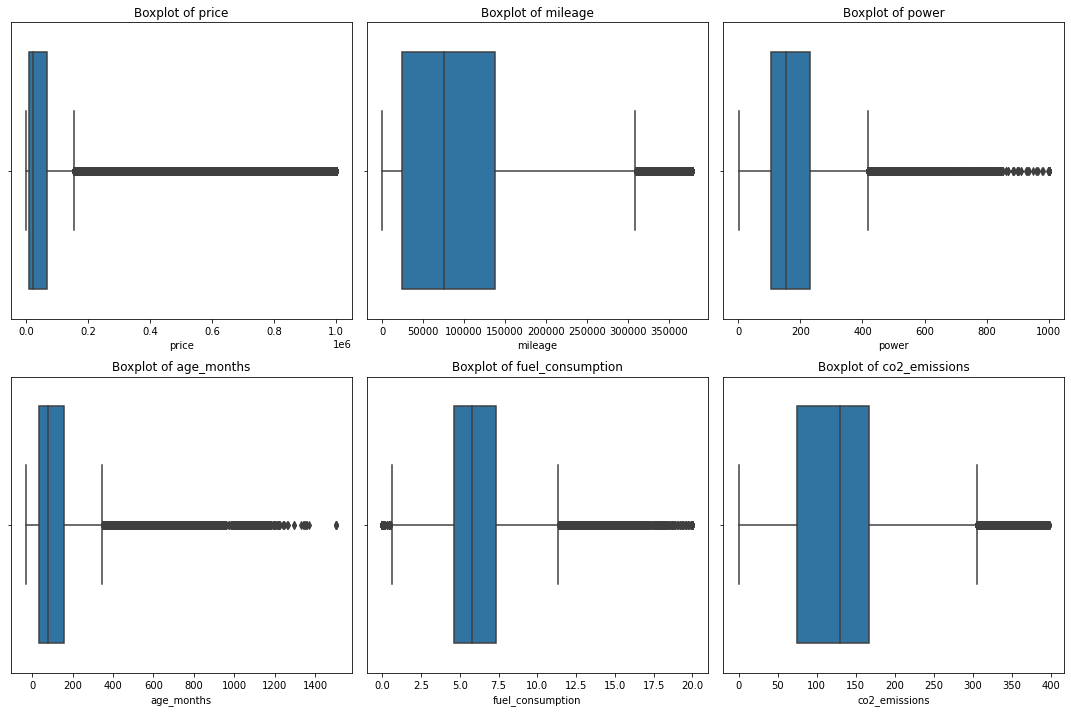

In [57]:
plot_numeric_columns(df)

We can see that we could do a lot better, especially regarding the price. Now, originally what we had done was clean by the 2 * IQR of the car make and then cap at 1 million euros max price.

This time we will do 1.5 IQR by car title and inspect what the output is.

In [14]:
# Function to clean outliers by car_title group using 1.5x IQR
def clean_by_car_title(group):
    Q1 = group["price"].quantile(0.25)
    Q3 = group["price"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return group[(group["price"] >= lower_bound) & (group["price"] <= upper_bound)]


# Apply cleaning by car_title groups
df_cleaned_per_title = df.groupby("car_title").apply(clean_by_car_title).reset_index(drop=True)

# Show the reduction in dataset size
cleaned_size = df_cleaned_per_title.shape[0]
print(f"Size after cleaning: {cleaned_size}")
print(f"Percentage kept: {cleaned_size/initial_size*100:.2f}%")

C:\Users\david\AppData\Local\Temp\ipykernel_18668\3297830484.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cleaned_per_title = df.groupby("car_title").apply(clean_by_car_title).reset_index(drop=True)


Size after cleaning: 443757
Percentage kept: 94.79%


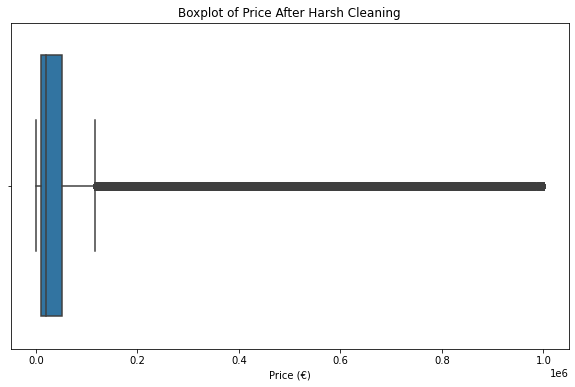

In [15]:
# Create boxplot for price feature
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_cleaned_per_title['price'])
plt.title('Boxplot of Price After Harsh Cleaning')
plt.xlabel('Price (€)')
plt.show()

Okay, that removed more than 5 percent of our dataset, but did not help at all with our price distribution. Now my next idea was to limit the price to a more normal price range which regular, everyday people could afford. Now 100k euros is not everyday by any means, but seems like a more reasonable high end for wealthy people.

In [16]:
df_100k_capped = df_cleaned_per_title[df_cleaned_per_title["price"] <= 100000]

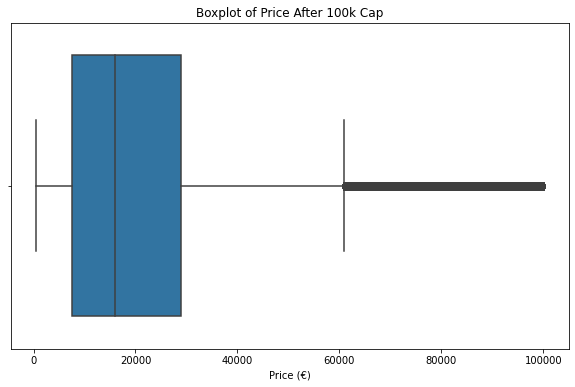

In [18]:
# Create boxplot for price feature
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_100k_capped['price'])
plt.title('Boxplot of Price After 100k Cap')
plt.xlabel('Price (€)')
plt.show()

Looks a lot better, but since we are really trying to do a harsh cleaning, let's do a 1.5 * IQR on this.

In [19]:
# Calculate IQR for price in the capped dataset
Q1 = df_100k_capped['price'].quantile(0.25)
Q3 = df_100k_capped['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outlier removal
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter dataset based on IQR bounds
df_cleaned = df_100k_capped[(df_100k_capped['price'] >= lower_bound) & (df_100k_capped['price'] <= upper_bound)]

# Show the reduction in dataset size
cleaned_size = df_cleaned.shape[0]
initial_size = df.shape[0]  # Original dataset size
print(f"Size after IQR cleaning: {cleaned_size}")
print(f"Percentage kept from original: {cleaned_size/initial_size*100:.2f}%")


Size after IQR cleaning: 341158
Percentage kept from original: 72.87%


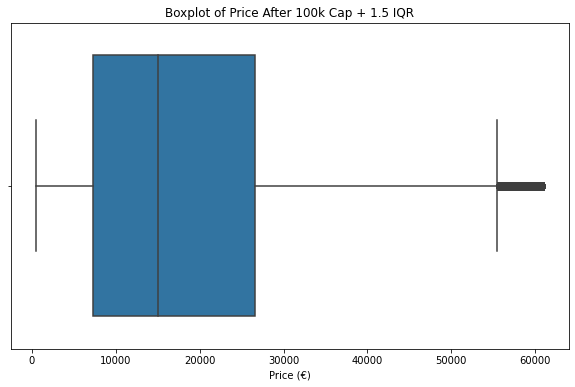

In [20]:
# Create boxplot for price feature
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_cleaned['price'])
plt.title('Boxplot of Price After 100k Cap + 1.5 IQR')
plt.xlabel('Price (€)')
plt.show()

We can see that the top-end is just above 60k euros and 73% of cars are below this line. 60k is about what a mid-level Mercedes-Benz costs. Now let's see the distribution of other features.

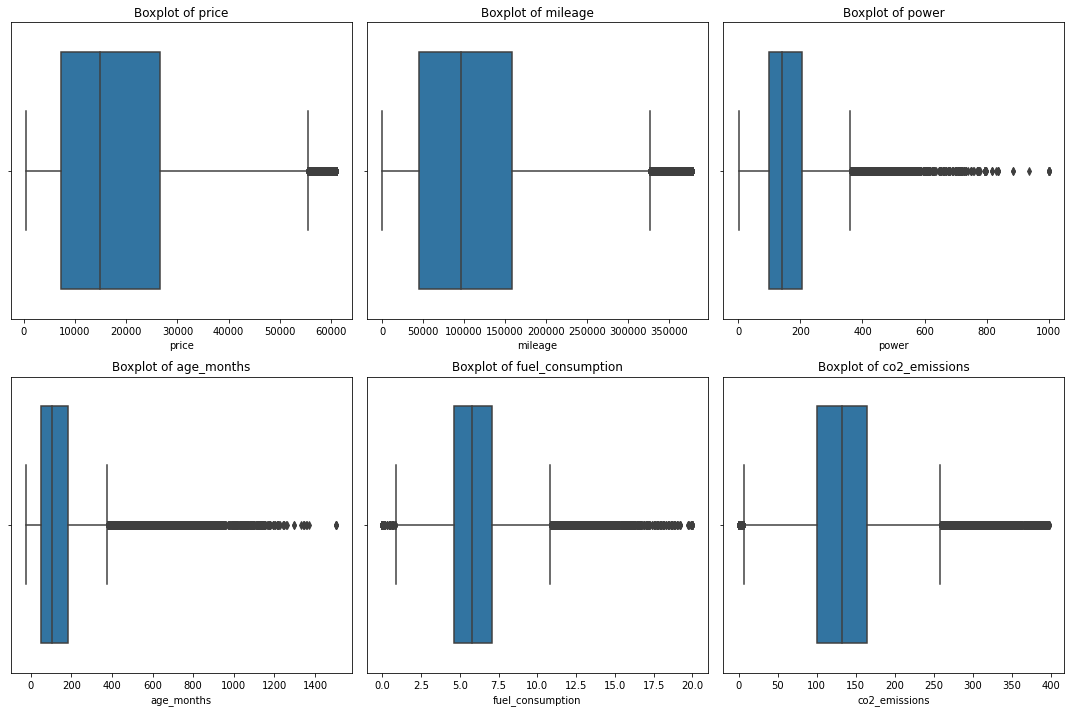

In [21]:
plot_numeric_columns(df_cleaned)

We still have to deal with `co2_emissions`, `age_months` and `fuel_consumption`. Let's do a 2 * IQR for all of these and see how the distributions look after. We had done sequential cleaning too as a first try for all columns, but as some of the variables are highly correlated it would clean too much of the data, we have to go through it step by step.

In [48]:
def clean_with_iqr(df, columns, iqr_multiplier=2):
    """
    Clean dataframe using IQR method for specified columns.
    
    Parameters:
    df (pd.DataFrame): Input dataframe
    columns (list): List of column names to clean
    iqr_multiplier (float): Multiplier for IQR bounds (default 2)
    
    Returns:
    pd.DataFrame: Cleaned dataframe
    """
    masks = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
        masks.append(mask)
    
    combined_mask = np.all(masks, axis=0)
    df_cleaned = df[combined_mask].copy()
    
    # Print comparison of rows
    print(f"Original rows: {initial_size}")
    print(f"Rows after {iqr_multiplier}*IQR cleaning: {len(df_cleaned)}")
    print(f"Percentage kept: {len(df_cleaned)/initial_size*100:.2f}%")
    
    return df_cleaned


In [53]:
df_cleaned_iqr = clean_with_iqr(df_cleaned, ['power'], iqr_multiplier=3)

Original rows: 468148
Rows after 3*IQR cleaning: 339236
Percentage kept: 72.46%


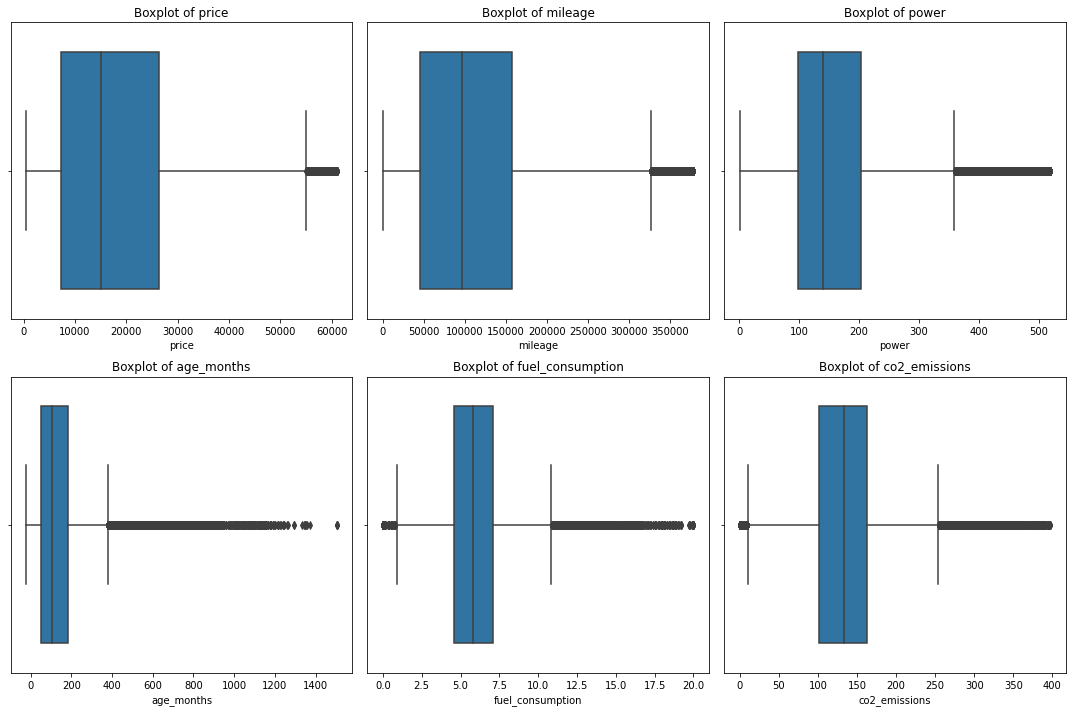

In [58]:
plot_numeric_columns(df_cleaned_iqr)

This has removed quite a lrage portion of the cars, so I will not clean this anymore. Let's now clean by `fuel_consumption`, but let's just cut it off at 15 and cut off `co2_emissions` at 300.

In [87]:
df_cleaned_final = df_cleaned_iqr.copy()

df_cleaned_final = df_cleaned_final[
    (df_cleaned_final["fuel_consumption"] <= 12)
    | (df_cleaned_final["fuel_consumption"].isna())
]

df_cleaned_final = df_cleaned_final[
    (df_cleaned_final["co2_emissions"] <= 300)
    | (df_cleaned_final["co2_emissions"].isna())
]

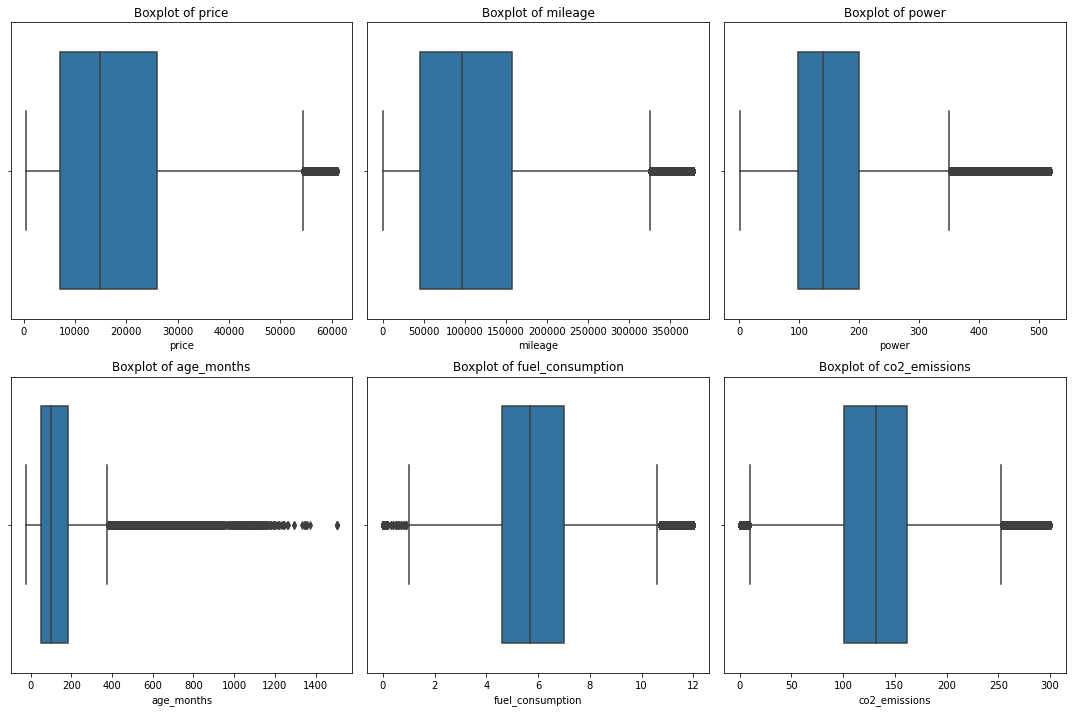

Original rows: 468148
Rows after capping: 335279
Percentage kept: 71.62%


In [88]:
plot_numeric_columns(df_cleaned_final)

# Print comparison of rows
print(f"Original rows: {initial_size}")
print(f"Rows after capping: {len(df_cleaned_final)}")
print(f"Percentage kept: {len(df_cleaned_final)/initial_size*100:.2f}%")

Finally let's clean `age_months`.

In [99]:
df_cleaned_final = df_cleaned_final[
    (df_cleaned_final["age_months"] <= 400)
    | (df_cleaned_final["age_months"].isna())
]

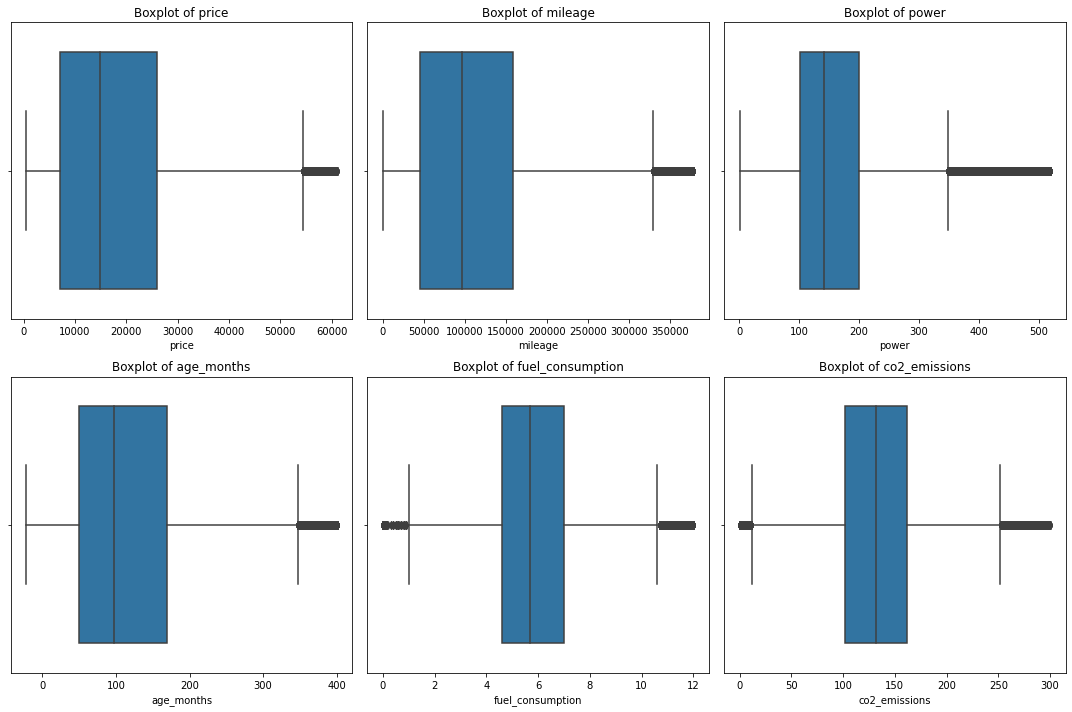

Original rows: 468148
Rows after capping: 319883
Percentage kept: 68.33%


In [100]:
plot_numeric_columns(df_cleaned_final)

# Print comparison of rows
print(f"Original rows: {initial_size}")
print(f"Rows after capping: {len(df_cleaned_final)}")
print(f"Percentage kept: {len(df_cleaned_final)/initial_size*100:.2f}%")

This leaves us with still more than 68% of our dataset which represents the average car well enough. Let's save this into a new dataset which we will use to build new models to compare with the base cleaned dataset.

In [101]:
df_cleaned_final.to_parquet(
    "../all_car_details_harshly_cleaned.parquet", compression="gzip"
)